# Hipotesis 3: Linea defensiva alta vs riesgo

Paso a paso: usamos freeze frames (360) para estimar altura
de la linea defensiva y la relacion con goles/ocasiones.

In [15]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [16]:
events_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\events\events_fact.parquet')
matches_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\matches\matches_fact.parquet')
freeze_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\\three_sixty\\three_sixty_freeze_frame.parquet')
events = pd.read_parquet(events_path)
matches = pd.read_parquet(matches_path)
freeze = pd.read_parquet(freeze_path)
events.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17276\3886843617.py:1: SyntaxWarning: invalid escape sequence '\C'
  events_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\events\events_fact.parquet')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17276\3886843617.py:2: SyntaxWarning: invalid escape sequence '\C'
  matches_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\matches\matches_fact.parquet')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17276\3886843617.py:3: SyntaxWarning: invalid escape sequence '\C'
  freeze_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\\three_sixty\\three_sixty_freeze_frame.parquet')


,event_id,match_id,index,period,timestamp,minute,second,event_type_id,event_type_name,team_id,...,possession_team_id,play_pattern_id,play_pattern_name,duration,under_pressure,related_events,x,y,end_x,end_y
0,0b483cd2-1d36-49a0-85c2-149a9de553df,7298,1,1,00:00:00.000,0,0,35,Starting XI,746,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
1,2c873afb-73bb-48a1-9fd5-bfe1400b4a83,7298,2,1,00:00:00.000,0,0,35,Starting XI,971,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
2,040940a1-5972-431e-b6ac-e723edd8e7c2,7298,3,1,00:00:00.000,0,0,18,Half Start,746,...,746,1,Regular Play,7.96,None,"[""5ba286bd-c397-4ac4-b12f-6bace943afce""]",NaN,NaN,NaN,NaN
3,5ba286bd-c397-4ac4-b12f-6bace943afce,7298,4,1,00:00:00.000,0,0,18,Half Start,971,...,746,1,Regular Play,8.16,None,"[""040940a1-5972-431e-b6ac-e723edd8e7c2""]",NaN,NaN,NaN,NaN
4,2a456ec2-352c-499b-b5cc-e68bf84c7e9a,7298,5,1,00:00:00.100,0,0,30,Pass,971,...,971,9,From Kick Off,0.00,None,"[""483b7286-e75e-4191-80be-ac93bfed1473""]",61.0,40.0,63.0,37.0


In [17]:
# Paso 1: unir 360 con eventos por evento
# event_uuid (360) coincide con event_id en events_fact
freeze = freeze.rename(columns={"event_uuid": "event_id"})

# Conservamos match_id desde 360 para evitar duplicados en el merge
events_cols = events[["event_id", "team_id", "event_type_name"]]
ff = freeze.merge(events_cols, on="event_id", how="left")
ff.head()

,event_id,match_id,x,y,teammate,actor,keeper,team_id,event_type_name
0,5c888f58-fe77-459b-ab3b-a2fa5fb8ab16,3788741,43.653216,31.988432,False,False,False,909,Pass
1,5c888f58-fe77-459b-ab3b-a2fa5fb8ab16,3788741,43.997359,45.599483,False,False,False,909,Pass
2,5c888f58-fe77-459b-ab3b-a2fa5fb8ab16,3788741,49.675716,35.434268,False,False,False,909,Pass
3,5c888f58-fe77-459b-ab3b-a2fa5fb8ab16,3788741,54.493715,30.093223,False,False,False,909,Pass
4,5c888f58-fe77-459b-ab3b-a2fa5fb8ab16,3788741,58.279286,48.528443,False,False,False,909,Pass


In [22]:
# Paso 2: estimar linea defensiva por evento
# Usamos jugadores NO teammates como defensores (oponentes del actor)
defensores = ff[ff["teammate"] == False].copy()
linea = (
    defensores.dropna(subset=["x"])
    .groupby(["event_id", "match_id"])["x"]
    .quantile(0.9)
    .reset_index(name="defensive_line_x")
)
linea.head()

# Paso 3: unir con goles totales del partido
matches["goles_total"] = matches["home_score"] + matches["away_score"]
linea_gc = linea.merge(matches[["match_id", "goles_total"]], on="match_id", how="left")
linea_gc.head()

,event_id,match_id,defensive_line_x,goles_total
0,000005b2-d8ff-4c0c-aa5c-2c91130fdc3b,3857256,57.444145,5
1,000018b5-08dc-4033-9a7a-7da41bc4597b,3857293,37.454797,2
2,00003aae-b8ee-419b-8b10-a3fdfe88314b,3938638,61.376127,3
3,00003c1e-3ebd-487d-b2fb-0907189b1227,3857255,44.654024,3
4,00004813-223b-4e1f-936f-4943ff66cc29,3930172,105.059280,1


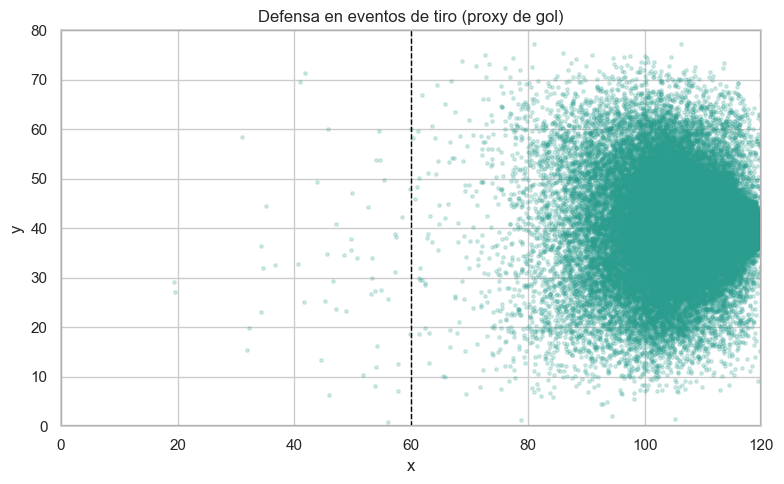

In [31]:
# Paso 3c: nube de puntos de defensa en eventos de tiro (proxy de gol)
fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

shots_def = ff[(ff["event_type_name"] == "Shot") & (ff["teammate"] == False)].dropna(subset=["x", "y"])
shots_def = shots_def.sample(min(len(shots_def), 50000), random_state=42)

plt.figure(figsize=(8, 5))
# campo 120x80
plt.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
plt.plot([60, 60], [0, 80], color="black", linestyle="--", linewidth=1)
plt.scatter(shots_def["x"], shots_def["y"], s=6, alpha=0.2, color="#2a9d8f")
plt.title("Defensa en eventos de tiro (proxy de gol)")
plt.xlim(0, 120)
plt.ylim(0, 80)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig(fig_dir / "h3_defensa_shots_scatter.png", dpi=160)
plt.show()

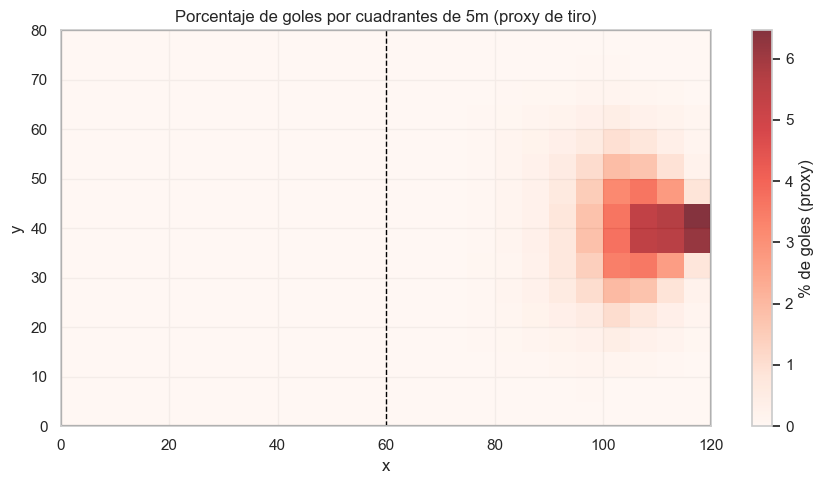

In [ ]:
# Paso 3d: heatmap por cuadrantes de 5 metros (porcentaje de goles)
fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Usamos solo eventos de gol
shots_def = ff[(ff["event_type_name"] == "Shot") & (ff["teammate"] == False)].dropna(subset=["x", "y"])
shots_def = shots_def.merge(
    events[["event_id", "shot_outcome"]],
    on="event_id",
    how="left",
)
shots_def = shots_def[shots_def["shot_outcome"] == "Goal"]

x_bins = np.arange(0, 125, 5)
y_bins = np.arange(0, 85, 5)

heat, x_edges, y_edges = np.histogram2d(shots_def["x"], shots_def["y"], bins=[x_bins, y_bins])
if heat.sum() > 0:
    heat_pct = (heat / heat.sum()) * 100
else:
    heat_pct = heat

plt.figure(figsize=(9, 5))
plt.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
plt.plot([60, 60], [0, 80], color="black", linestyle="--", linewidth=1)

# pcolormesh requiere matriz transpuesta por orientacion
plt.pcolormesh(x_edges, y_edges, heat_pct.T, cmap="Reds", shading="auto", alpha=0.8)
plt.colorbar(label="% de goles")

plt.title("Porcentaje de goles por cuadrantes de 5m")
plt.xlim(0, 120)
plt.ylim(0, 80)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig(fig_dir / "h3_goles_cuadrantes_5m.png", dpi=160)
plt.show()

In [25]:
# Paso 4: resumen por partido
resumen = (
    linea_gc.groupby("match_id")
    .agg(defensive_line_x=("defensive_line_x", "mean"), goles_total=("goles_total", "mean"))
    .reset_index()
)
resumen.corr(numeric_only=True)

,match_id,defensive_line_x,goles_total
match_id,1.000000,-0.013834,0.024597
defensive_line_x,-0.013834,1.000000,0.041070
goles_total,0.024597,0.041070,1.000000


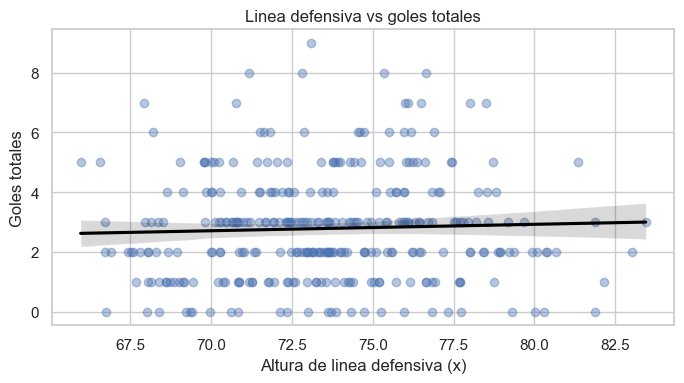

In [26]:
# Paso 4b: relacion linea defensiva vs goles totales
plt.figure(figsize=(7, 4))
sns.regplot(data=resumen, x="defensive_line_x", y="goles_total", scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
plt.title("Linea defensiva vs goles totales")
plt.xlabel("Altura de linea defensiva (x)")
plt.ylabel("Goles totales")
plt.tight_layout()
plt.savefig(fig_dir / "h3_linea_vs_goles.png", dpi=160)
plt.show()